In [2]:
# Energy Minimization for DKJ Shell Equation
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ===========================================
# Neural Network for DKJ Shell Equation
# Outputs: w, Φ
# ===========================================
class DKJShellNN(nn.Module):
    def __init__(self, input_size=2, hidden_size=200, output_size=2, depth=10):
        super(DKJShellNN, self).__init__()
        layers = [nn.Linear(input_size, hidden_size), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden_size, hidden_size), nn.Tanh()]
        layers.append(nn.Linear(hidden_size, output_size))  # Outputs: w, Φ where: Φ=Airy Stress Function
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

# ===========================================
# PINN Class for DKJ Shell PDE (Energy Minimization)
# ===========================================
class DKJShellPINN:
    def __init__(self, h=0.01, R=0.5, D=1.0, L=1.0, N_train=1000, q0=-5.0, nu=0.3):
        self.h, self.R, self.D, self.L, self.q0, self.nu = h, R, D, L, q0, nu
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Using device: {self.device}")
        self.model = DKJShellNN().to(self.device)

        n = int(np.sqrt(N_train))
        x = torch.linspace(0, L, n).to(self.device)
        phi = torch.linspace(0, 2 * np.pi, n).to(self.device)
        X, Phi = torch.meshgrid(x, phi, indexing='ij')
        self.X_train = torch.stack([X.reshape(-1), Phi.reshape(-1)], dim=1).requires_grad_(True)

        N_bc = max(100, n // 2)
        phi_bc = torch.linspace(0, 2 * np.pi, N_bc).to(self.device)
        x0 = torch.zeros(N_bc).to(self.device)
        xL = torch.full((N_bc,), L).to(self.device)
        X_bc0 = torch.stack([x0, phi_bc], dim=1).requires_grad_(True)
        X_bcL = torch.stack([xL, phi_bc], dim=1).requires_grad_(True)
        self.X_bc = torch.cat([X_bc0, X_bcL], dim=0)

        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=1e-5)
        #self.scheduler = torch.optim.lr_scheduler.StepLR(self.optimizer, step_size=20, gamma=0.5)
        self.criterion = nn.MSELoss()
        self.loss_history = []

    def compute_derivatives(self, output, inputs, idx, order):
        for _ in range(order):
            output = torch.autograd.grad(output, inputs, grad_outputs=torch.ones_like(output),
                                         create_graph=True, retain_graph=True)[0][:, idx:idx + 1]
        return output

    def laplacian(self, f, X):
        d2f_dx2 = self.compute_derivatives(f, X, idx=0, order=2)
        d2f_dphi2 = self.compute_derivatives(f, X, idx=1, order=2)
        return d2f_dx2 + (1 / self.R ** 2) * d2f_dphi2

    def biharmonic(self, f, X):
        return self.laplacian(self.laplacian(f, X), X)

    # -------------------------------------------
    # Energy functional U[w, Φ]
    # U = (D/2)∫(∆2w)^2dxdφ + (h/R^2)∫(∅4w/∂x^4)^2dxdφ 
    #     + (1/2Eh)∫[ (∂2Φ/∂φ2)ε_x + (∂2Φ/∂x2)ε_φ - 2(∂2Φ/∂x∂φ)γ_xφ ]dxdφ
    # -------------------------------------------
    def compute_energy_loss(self):
        X = self.X_train
        out = self.model(X)
        raw_w, Phi = out[:, 0:1], out[:, 1:2]
        x_vals = X[:, 0:1]
        L = self.L
        w = x_vals * (L - x_vals) * raw_w

        ε_x = self.compute_derivatives(w, X, 0, 1)
        ε_φ = (1 / self.R) * self.compute_derivatives(w, X, 1, 1)
        γ_xφ = ε_x + ε_φ

        biharm_w = self.biharmonic(w, X)
        d4w_dx4 = self.compute_derivatives(w, X, 0, 4)

        d2Phi_dphi2 = self.compute_derivatives(Phi, X, 1, 2)
        d2Phi_dx2 = self.compute_derivatives(Phi, X, 0, 2)
        d2Phi_dxphi = self.compute_derivatives(Phi, X, 0, 1)
        d2Phi_dxphi = self.compute_derivatives(d2Phi_dxphi, X, 1, 1)

        E1 = (self.D / 2) * torch.mean(biharm_w ** 2)
        E2 = (self.h / self.R ** 2) * torch.mean(d4w_dx4 ** 2)
        raw_E3 = (1 / (2 * self.h * self.D * 12 * (1 - self.nu ** 2))) * torch.mean(
            d2Phi_dphi2 * ε_x + d2Phi_dx2 * ε_φ - 2 * d2Phi_dxphi * γ_xφ)
        E3 = torch.clamp(raw_E3, min=0.0)

        #Point Load
        x_vals = X[:, 0:1]
        phi_vals = X[:, 1:2]
        distance = torch.sqrt((x_vals - 0.5)**2 + (phi_vals - 0.0)**2)
        threshold = 0.01  # small radius around the point to simulate point load
        load_mask = (distance < threshold)
        if load_mask.sum() > 0:
            W_ext = self.q0 * torch.mean(w[load_mask])  # W_ext = q0 · w(x0, φ0)
        else:
            W_ext = 0.0

        #Boundary Condition Loss
        out_bc = self.model(self.X_bc)
        w_bc = out_bc[:, 0:1]
        d2w_dx2_bc = self.compute_derivatives(w_bc, self.X_bc, 0, 2)

        energy_loss = E1 + E2 + E3
        alpha = 1e6 * energy_loss.detach()
        bc_loss = alpha * (self.criterion(w_bc, torch.zeros_like(w_bc)) +
                           self.criterion(d2w_dx2_bc, torch.zeros_like(d2w_dx2_bc)))

        #Total Loss
        total_loss = energy_loss - W_ext + bc_loss
        #total_loss = torch.clamp(total_loss, min=0.0)
        return total_loss

    def train(self, epochs=2001):
        for epoch in range(epochs):
            self.optimizer.zero_grad()
            loss = self.compute_energy_loss()
            loss.backward()
            self.optimizer.step()
            self.loss_history.append(loss.item())
            if epoch % 100 == 0 or epoch == epochs - 1:
                print(f"Epoch {epoch}: Loss = {loss.item():.20f}")

    def predict_w(self, x_vals, phi_val):
        x_tensor = torch.tensor(x_vals, dtype=torch.float32).view(-1, 1).to(self.device)
        phi_tensor = torch.full_like(x_tensor, phi_val).to(self.device)
        X_pred = torch.cat([x_tensor, phi_tensor], dim=1)

        with torch.no_grad():
            out = self.model(X_pred)
            raw_w = out[:, 0:1]
            w = x_tensor * (self.L - x_tensor) * raw_w  # Enforce w=0 at x=0 and x=L
        return w[:, 0].cpu().numpy()

    def predict_w_grid(self, x_vals, phi_vals):
        X_grid, Phi_grid = np.meshgrid(x_vals, phi_vals, indexing='ij')
        x_flat = X_grid.flatten()
        phi_flat = Phi_grid.flatten()

        x_tensor = torch.tensor(x_flat, dtype=torch.float32).view(-1, 1).to(self.device)
        phi_tensor = torch.tensor(phi_flat, dtype=torch.float32).view(-1, 1).to(self.device)
        X_pred = torch.cat([x_tensor, phi_tensor], dim=1)

        with torch.no_grad():
            out = self.model(X_pred)
            raw_w = out[:, 0:1]
            w = x_tensor * (self.L - x_tensor) * raw_w  # Enforce w=0 at x=0 and x=L
            w = w.view(X_grid.shape)

        return X_grid, Phi_grid, w.cpu().numpy()

# ===========================================
# Main script: Train
# ===========================================
if __name__ == "__main__":
    shell_pinn = DKJShellPINN(q0=-5.0)  # Load magnitude q0=1.0 (uniform pressure)
    shell_pinn.train(epochs=5001)

Using device: cuda
Epoch 0: Loss = 0.13090942800045013428
Epoch 100: Loss = -0.00341120199300348759
Epoch 200: Loss = -0.00712932180613279343
Epoch 300: Loss = -0.00641078967601060867
Epoch 400: Loss = -0.00613949727267026901
Epoch 500: Loss = -0.00606026966124773026
Epoch 600: Loss = -0.00590721331536769867
Epoch 700: Loss = -0.00573147274553775787
Epoch 800: Loss = -0.00561126554384827614
Epoch 900: Loss = -0.00555987656116485596
Epoch 1000: Loss = -0.00554209528490900993
Epoch 1100: Loss = -0.00553461955860257149
Epoch 1200: Loss = -0.00553086819127202034
Epoch 1300: Loss = -0.00553074711933732033
Epoch 1400: Loss = -0.00553571386262774467
Epoch 1500: Loss = -0.00554783269762992859
Epoch 1600: Loss = -0.00556971179321408272
Epoch 1700: Loss = -0.00560518819838762283
Epoch 1800: Loss = -0.00565785448998212814
Epoch 1900: Loss = -0.00571379996836185455
Epoch 2000: Loss = -0.00565411522984504700
Epoch 2100: Loss = -0.00537100713700056076
Epoch 2200: Loss = -0.00527993123978376389
Epoch

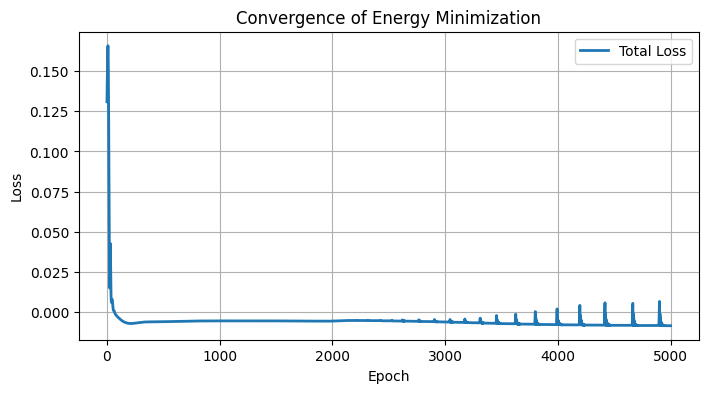

In [3]:
# Plot convergence
plt.figure(figsize=(8, 4))
plt.plot(shell_pinn.loss_history, label="Total Loss", linewidth=2)
#plt.yscale('log')  # Optional: use log scale for better visualization
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Convergence of Energy Minimization")
plt.grid(True)
plt.legend()
plt.show()

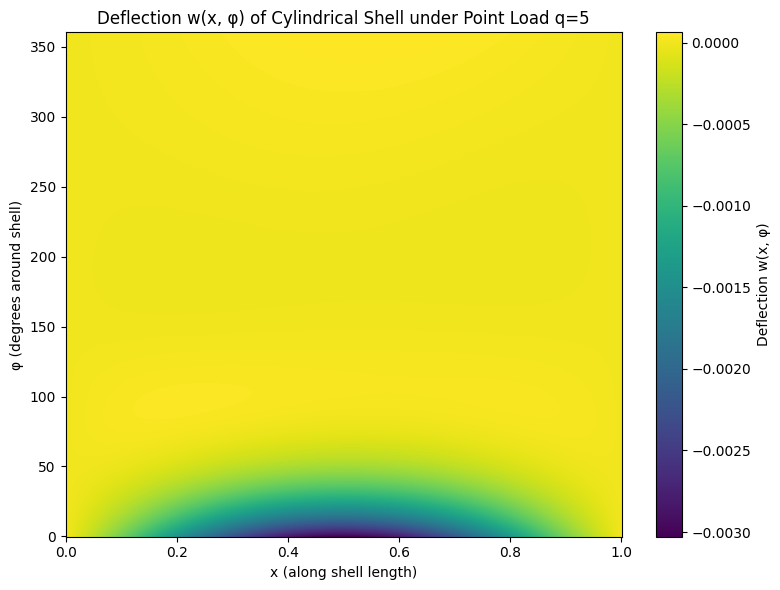

In [4]:
# Generate grid and model predictions
x_plot = np.linspace(0, shell_pinn.L, 1000)
phi_plot = np.linspace(0, 2 * np.pi, 1000)
X, Phi, w = shell_pinn.predict_w_grid(x_plot, phi_plot)

# 2D contour plot for deflection w(x, φ)
plt.figure(figsize=(8, 6))

# Convert φ to degrees for better interpretability
phi_degrees = np.degrees(Phi)
levels = np.linspace(np.min(w), np.max(w), 100)

# Plot using pcolormesh for higher clarity and resolution
cp = plt.pcolormesh(X, phi_degrees, w, shading='auto', cmap='viridis')
plt.colorbar(cp, label='Deflection w(x, φ)')

plt.xlabel('x (along shell length)')
plt.ylabel('φ (degrees around shell)')
plt.title('Deflection w(x, φ) of Cylindrical Shell under Point Load q=5')
plt.tight_layout()
plt.show()

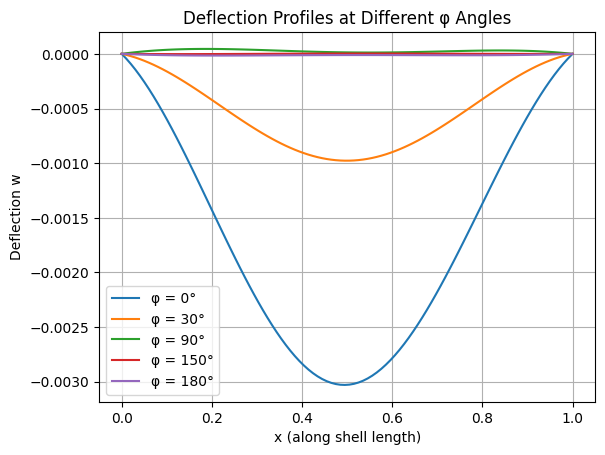

In [5]:
import matplotlib.pyplot as plt
import numpy as np

x_plot = np.linspace(0, 1.0, 100)  # or use shell_pinn.L if defined

# Plot deflection at different φ slices
phi_degrees_list = [0, 30, 90, 150, 180]

for phi_deg in phi_degrees_list:
    phi_rad = np.radians(phi_deg)  # ✅ Convert degrees to radians
    w_vals = shell_pinn.predict_w(x_plot, phi_rad)
    plt.plot(x_plot, w_vals, label=f'φ = {phi_deg}°')

plt.xlabel("x (along shell length)")
plt.ylabel("Deflection w")
plt.title("Deflection Profiles at Different φ Angles")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
# ===========================================
# List deflections at x in [0, L] step 0.1 and φ in [0, 2π] every 45°
# ===========================================
x_points = np.arange(0, shell_pinn.L + 0.001, 0.1)
phi_degrees = np.arange(0, 361, 45)
phi_radians = np.deg2rad(phi_degrees)

print("\nDeflection w(x, φ):")
for x in x_points:
    print(f"\nAt x = {x:.2f}:")
    for phi_deg, phi in zip(phi_degrees, phi_radians):
        w_pred = shell_pinn.predict_w([x], phi)
        print(f"  φ = {phi_deg:3d}° -> w = {w_pred[0]:.6f}")


Deflection w(x, φ):

At x = 0.00:
  φ =   0° -> w = -0.000000
  φ =  45° -> w = -0.000000
  φ =  90° -> w = 0.000000
  φ = 135° -> w = 0.000000
  φ = 180° -> w = -0.000000
  φ = 225° -> w = -0.000000
  φ = 270° -> w = -0.000000
  φ = 315° -> w = 0.000000
  φ = 360° -> w = 0.000000

At x = 0.10:
  φ =   0° -> w = -0.000599
  φ =  45° -> w = -0.000058
  φ =  90° -> w = 0.000037
  φ = 135° -> w = 0.000008
  φ = 180° -> w = -0.000012
  φ = 225° -> w = -0.000009
  φ = 270° -> w = -0.000000
  φ = 315° -> w = 0.000007
  φ = 360° -> w = 0.000012

At x = 0.20:
  φ =   0° -> w = -0.001428
  φ =  45° -> w = -0.000181
  φ =  90° -> w = 0.000045
  φ = 135° -> w = 0.000012
  φ = 180° -> w = -0.000016
  φ = 225° -> w = -0.000010
  φ = 270° -> w = 0.000005
  φ = 315° -> w = 0.000018
  φ = 360° -> w = 0.000028

At x = 0.30:
  φ =   0° -> w = -0.002250
  φ =  45° -> w = -0.000322
  φ =  90° -> w = 0.000036
  φ = 135° -> w = 0.000014
  φ = 180° -> w = -0.000015
  φ = 225° -> w = -0.000008
  φ = 270° -> 

In [ ]:
#3D
x_plot = np.linspace(0, shell_pinn.L, 50)
phi_plot = np.linspace(0, 2 * np.pi, 50)
X, Phi, w = shell_pinn.predict_w_grid(x_plot, phi_plot)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Original shell coordinates + displacement
Y = np.cos(Phi) * (shell_pinn.R + w)  
Z = np.sin(Phi) * (shell_pinn.R + w)

# Plot the deformed shell surface
surf = ax.plot_surface(X, Y, Z, cmap='jet', alpha=0.8)

fig.colorbar(surf, ax=ax, label='Displacement w')
ax.set_xlabel('x (Length)')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.title('DKJ Shell Deformation under Point Load (q0=5.0)')

# Add legend manually for load region
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', edgecolor='r', alpha=0.3, label='Load Applied (Uniform)')]
ax.legend(handles=legend_elements, loc='upper right')

plt.show()

In [ ]:
    # Plotting the 3D deformation
    n_plot = 50
    x_plot = np.linspace(0, shell_pinn.L, n_plot)
    phi_plot = np.linspace(0, 2 * np.pi, n_plot)

    X_grid_orig, Phi_grid_orig, w_pred = shell_pinn.predict_w_grid(x_plot, phi_plot)

    # Convert cylindrical coordinates (x, phi, R) to Cartesian (X, Y, Z) for plotting
    R_shell = shell_pinn.R

    # Original shell coordinates (un-deformed)
    X_orig_cart = X_grid_orig
    Y_orig_cart = R_shell * np.cos(Phi_grid_orig)
    Z_orig_cart = R_shell * np.sin(Phi_grid_orig)

    # Deformed shell coordinates (w is radial displacement)
    # The displacement 'w' is perpendicular to the shell surface (radial).
    # So, we add w along the normal direction. For a cylindrical shell, the normal is in the YZ plane.
    # New radius becomes R + w
    Y_deformed_cart = (R_shell + w_pred) * np.cos(Phi_grid_orig)
    Z_deformed_cart = (R_shell + w_pred) * np.sin(Phi_grid_orig)
    X_deformed_cart = X_grid_orig # Assuming x-axis remains the same for simplicity in visualization of radial deformation

    # Create figure for 3D plots
    fig = plt.figure(figsize=(15, 7))

    # Plot 1: Original Shell
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.plot_surface(X_orig_cart, Y_orig_cart, Z_orig_cart, alpha=0.5, color='blue', rstride=1, cstride=1)
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    ax1.set_title('Original Cylindrical Shell')
    # Set equal aspect ratio
    ax1.set_box_aspect([np.ptp(X_orig_cart), np.ptp(Y_orig_cart), np.ptp(Z_orig_cart)])

    # Plot 2: Deformed Shell
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.plot_surface(X_deformed_cart, Y_deformed_cart, Z_deformed_cart, alpha=0.7, color='red', rstride=1, cstride=1)
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_zlabel('Z')
    ax2.set_title('Deformed Cylindrical Shell')
    # Set equal aspect ratio
    ax2.set_box_aspect([np.ptp(X_deformed_cart), np.ptp(Y_deformed_cart), np.ptp(Z_deformed_cart)])

    plt.tight_layout()
    plt.show()

    # Plotting w as a 2D surface (x vs phi)
    fig_w = plt.figure(figsize=(10, 8))
    ax_w = fig_w.add_subplot(111, projection='3d')
    ax_w.plot_surface(X_grid_orig, Phi_grid_orig, w_pred, cmap='viridis', rstride=1, cstride=1)
    ax_w.set_xlabel('x (axial)')
    ax_w.set_ylabel('phi (circumferential)')
    ax_w.set_zlabel('w (radial displacement)')
    ax_w.set_title('Radial Displacement (w) on x-phi Plane')
    plt.show()

    # Plotting cross-section of w at a specific phi (e.g., phi = 0)
    phi_slice_idx = np.argmin(np.abs(phi_plot - 0.0))
    w_slice = w_pred[:, phi_slice_idx]

    plt.figure(figsize=(8, 6))
    plt.plot(x_plot, w_slice, label=f'w at phi = {phi_plot[phi_slice_idx]:.2f} radians')
    plt.xlabel('x (axial coordinate)')
    plt.ylabel('w (radial displacement)')
    plt.title('Radial Displacement (w) along the length at a specific circumferential angle')
    plt.grid(True)
    plt.legend()
    plt.show()

    # Plotting loss history
    plt.figure(figsize=(10, 6))
    plt.plot(shell_pinn.loss_history)
    plt.yscale('log')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (log scale)')
    plt.title('Training Loss History')
    plt.grid(True)
    plt.show()